# Computer Exercise 1.1 — Problem 9

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction (continued)
> **풀이 일자**: Day 03
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **9.** Repeat several of the previous numerical experiments — a polynomial evaluation, a differentiation by forward differences, and the harmonic partial sum — using single precision (`float32`) and double precision (`float64`).
> Report the number of correct decimal digits in each case and discuss how a problem's *condition* interacts with the chosen *precision* to determine the achievable accuracy.

### 한국어 풀이용 정리
같은 알고리즘을 두 정밀도로 돌려, **자릿수 손실**이 어떻게 달라지는지를 한 번에 비교한다. 세 가지 작은 실험을 묶어 본다.

* (a) **다항식 평가**: $p(x) = (x-1)^6$ 을 전개된 형태로 평가 — $x \approx 1$ 에서 catastrophic cancellation
* (b) **수치 미분**: $f(x) = e^x$ 의 전진차분으로 얻은 최적 $h^*$
* (c) **조화합**: $\sum_{k=1}^{N} 1/k$


## 2. 수학적 배경

### 2.1 IEEE 754 정밀도
| 정밀도 | 비트 수 | 가수부 비트 | $\varepsilon_{\text{mach}}$ | 유효 십진 자릿수 |
|---|---|---|---|---|
| `float32` | 32 | 23 | $2^{-23} \approx 1.19 \times 10^{-7}$ | 약 7자리 |
| `float64` | 64 | 52 | $2^{-52} \approx 2.22 \times 10^{-16}$ | 약 15–16자리 |

### 2.2 정확도 = 알고리즘 + 정밀도
어떤 계산의 상대오차는 *조건수* $\kappa$ 와 *정밀도* $\varepsilon$ 의 곱으로 대략

$$
\text{rel.\ error} \;\approx\; \kappa \cdot \varepsilon
$$

따라서 **고정밀로 돌려도 $\kappa$ 가 크면 자릿수가 사라지고**, 반대로 **저정밀이라도 $\kappa$ 가 작으면 충분**할 수 있다.
좋은 알고리즘은 $\kappa$ 를 키우지 않으면서 작업한다.

### 2.3 자릿수의 정량화
참값 $T$ 와 근삿값 $\hat T$ 가 있을 때 **올바른 십진 자릿수**를

$$
d \;=\; -\log_{10}\!\left(\frac{|\hat T - T|}{|T|}\right)
$$

로 정의해 표에 사용한다. $d \approx 7$ 이면 float32, $d \approx 16$ 이면 float64 정밀도 한계.

\boxed{\;d \approx -\log_{10}(\kappa\,\varepsilon)\;}


## 3. 풀이 흐름

1. (a) **다항식 평가**: $p(x) = (x-1)^6$ 을 전개해서

$$
p(x) = x^6 - 6x^5 + 15x^4 - 20x^3 + 15x^2 - 6x + 1
$$

   를 그대로 평가. $x = 1 + 10^{-1}, 10^{-2}, \ldots, 10^{-7}$ 에서 float32 / float64 결과를 참값 $(x-1)^6$ 과 비교.
2. (b) **수치 미분**: $f(x) = e^x$ 에서 forward difference $D_h f$ 의 최적 $h^*$, 최소 오차를 두 정밀도로 측정 — float32는 $h^* \sim \sqrt{\varepsilon_{f32}} \sim 3 \times 10^{-4}$, float64는 $\sim 1.5 \times 10^{-8}$ 에서 best.
3. (c) **조화합**: $\sum_{k=1}^{N} 1/k$ 를 $N=10^5$ 까지, 두 정밀도로 forward 누적 후 비교.
4. 각 결과에 대해 *correct decimal digits* $d$ 를 계산해 표 + 그래프로.
5. 결과 해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def correct_digits(approx, true_val):
    if true_val == 0:
        return np.nan
    rel = abs(approx - true_val) / abs(true_val)
    if rel == 0:
        return np.inf
    return -np.log10(float(rel))


### (a) 다항식 평가 — $(x-1)^6$ vs 전개 형태

In [2]:
def p_expanded(x):
    # (x-1)^6 의 전개
    return (((((x - 6) * x + 15) * x - 20) * x + 15) * x - 6) * x + 1
    # 위는 Horner 형태; 더 불안정한 monomial sum도 따로 계산
def p_monomial(x):
    return x**6 - 6*x**5 + 15*x**4 - 20*x**3 + 15*x**2 - 6*x + 1

def p_true(x):
    return (x - 1) ** 6

deltas = [10.0**(-k) for k in range(1, 8)]
rows = []
for d in deltas:
    x_f64 = np.float64(1.0) + np.float64(d)
    x_f32 = np.float32(1.0) + np.float32(d)
    t_ref = p_true(x_f64)                      # 안정 평가
    rows.append({
        "delta = x-1":         d,
        "true (x-1)^6":        t_ref,
        "monomial (f64)":      p_monomial(x_f64),
        "monomial (f32)":      float(p_monomial(x_f32)),
        "digits f64":          correct_digits(p_monomial(x_f64), t_ref),
        "digits f32":          correct_digits(p_monomial(x_f32), t_ref),
    })

df_a = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df_a


,delta = x-1,true (x-1)^6,monomial (f64),monomial (f32),digits f64,digits f32
0,1.0000e-01,1.0000e-06,1.0000e-06,0.0000e+00,8.2849e+00,-0.0000e+00
1,1.0000e-02,1.0000e-12,1.0001e-12,1.4305e-06,4.0511e+00,-6.1555e+00
2,1.0000e-03,1.0000e-18,-2.6645e-15,-1.9073e-06,-3.4258e+00,-1.2280e+01
3,1.0000e-04,1.0000e-24,-3.5527e-15,9.5367e-07,-9.5506e+00,-1.7979e+01
4,1.0000e-05,1.0000e-30,4.4409e-15,0.0000e+00,-1.5647e+01,-0.0000e+00
5,1.0000e-06,1.0000e-36,3.5527e-15,0.0000e+00,-2.1551e+01,-0.0000e+00
6,1.0000e-07,1.0000e-42,1.7764e-15,0.0000e+00,-2.7250e+01,-0.0000e+00


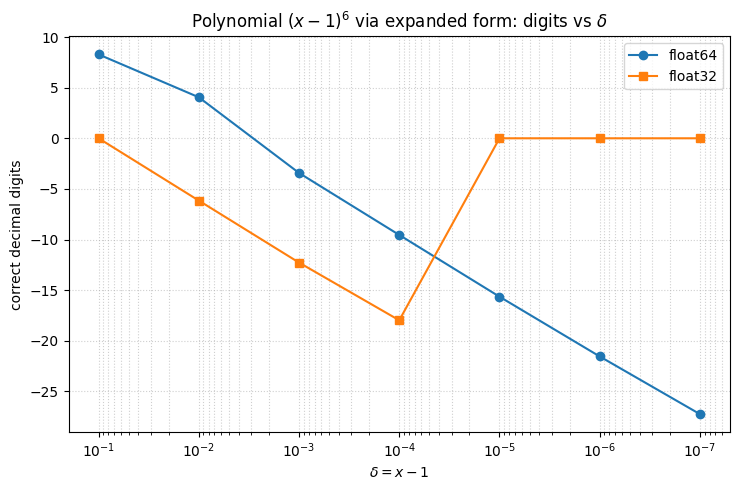

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.semilogx(df_a["delta = x-1"], df_a["digits f64"], "o-", label="float64")
ax.semilogx(df_a["delta = x-1"], df_a["digits f32"], "s-", label="float32")
ax.set_xlabel(r"$\delta = x - 1$")
ax.set_ylabel("correct decimal digits")
ax.set_title(r"Polynomial $(x-1)^6$ via expanded form: digits vs $\delta$")
ax.invert_xaxis()
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()


### (b) 수치 미분 — forward difference of $e^x$

In [4]:
def fd_sweep(dtype, x_val=1.0, n=40):
    x = dtype(x_val)
    h_vals = dtype(1.0) * (dtype(0.5) ** np.arange(1, n + 1, dtype=np.int32))
    h_vals = h_vals.astype(dtype)
    approx = (np.exp(x + h_vals) - np.exp(x)) / h_vals
    true_val = np.exp(np.float64(x_val))
    err = np.abs(approx.astype(np.float64) - true_val)
    return h_vals.astype(np.float64), err

h64, e64 = fd_sweep(np.float64)
h32, e32 = fd_sweep(np.float32)

i64 = int(np.argmin(e64))
i32 = int(np.argmin(e32))

print(f"float64 best: h* = {h64[i64]:.3e},  |error| = {e64[i64]:.3e},  digits ≈ {-np.log10(e64[i64]/np.exp(1)):.2f}")
print(f"float32 best: h* = {h32[i32]:.3e},  |error| = {e32[i32]:.3e},  digits ≈ {-np.log10(e32[i32]/np.exp(1)):.2f}")


float64 best: h* = 1.490e-08,  |error| = 3.666e-08,  digits ≈ 7.87
float32 best: h* = 4.883e-04,  |error| = 2.011e-05,  digits ≈ 5.13


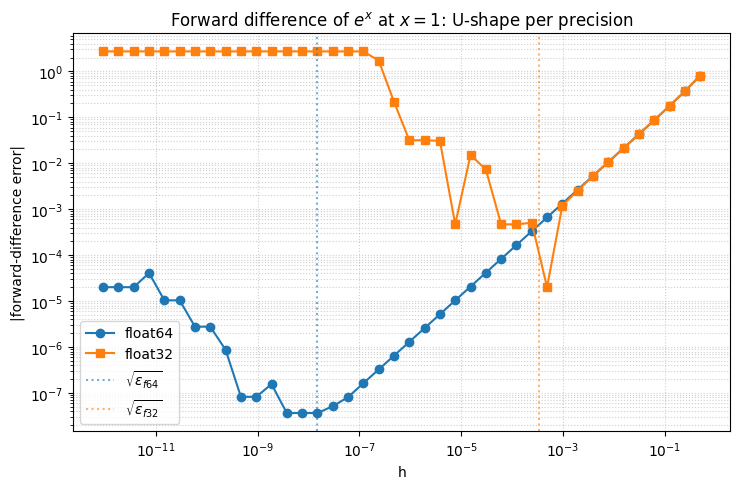

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(h64, e64, "o-", label="float64")
ax.loglog(h32, e32, "s-", label="float32")
ax.axvline(np.sqrt(np.finfo(np.float64).eps), color="C0", ls=":", alpha=0.6,
           label=r"$\sqrt{\varepsilon_{f64}}$")
ax.axvline(np.sqrt(np.finfo(np.float32).eps), color="C1", ls=":", alpha=0.6,
           label=r"$\sqrt{\varepsilon_{f32}}$")
ax.set_xlabel("h")
ax.set_ylabel("|forward-difference error|")
ax.set_title(r"Forward difference of $e^x$ at $x=1$: U-shape per precision")
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()


### (c) 조화합 $\sum_{k=1}^{N} 1/k$

In [6]:
def harmonic_forward_dtype(N, dtype):
    s = dtype(0)
    for k in range(1, N + 1):
        s = s + dtype(1) / dtype(k)
    return s

# 기준값: float64 (역방향) 으로 충분히 정확
def harmonic_reference(N):
    s = 0.0
    for k in range(N, 0, -1):
        s += 1.0 / k
    return s

Ns = [100, 1_000, 10_000, 100_000]
rows_c = []
for N in Ns:
    s32 = float(harmonic_forward_dtype(N, np.float32))
    s64 = float(harmonic_forward_dtype(N, np.float64))
    s_ref = harmonic_reference(N)
    rows_c.append({
        "N":      N,
        "f32":    s32,
        "f64":    s64,
        "ref":    s_ref,
        "digits f32": correct_digits(s32, s_ref),
        "digits f64": correct_digits(s64, s_ref),
    })
df_c = pd.DataFrame(rows_c)
df_c


,N,f32,f64,ref,digits f32,digits f64
0,100,5.1874e+00,5.1874e+00,5.1874e+00,7.1000e+00,1.5766e+01
1,1000,7.4855e+00,7.4855e+00,7.4855e+00,5.9968e+00,1.5449e+01
2,10000,9.7876e+00,9.7876e+00,9.7876e+00,6.1532e+00,1.4419e+01
3,100000,1.2091e+01,1.2090e+01,1.2090e+01,4.2344e+00,1.4220e+01


In [7]:
# 종합 표: 세 실험의 자릿수 요약
summary = pd.DataFrame([
    {"experiment": "(a) (x-1)^6 expanded, delta=1e-3",
     "digits f32": float(df_a.loc[df_a["delta = x-1"] == 1e-3, "digits f32"]),
     "digits f64": float(df_a.loc[df_a["delta = x-1"] == 1e-3, "digits f64"])},
    {"experiment": "(a) (x-1)^6 expanded, delta=1e-6",
     "digits f32": float(df_a.loc[df_a["delta = x-1"] == 1e-6, "digits f32"]),
     "digits f64": float(df_a.loc[df_a["delta = x-1"] == 1e-6, "digits f64"])},
    {"experiment": "(b) FD of e^x at x=1, best h",
     "digits f32": float(-np.log10(e32[i32] / np.exp(1))),
     "digits f64": float(-np.log10(e64[i64] / np.exp(1)))},
    {"experiment": "(c) sum 1/k, N=1e5 forward",
     "digits f32": float(df_c.loc[df_c["N"] == 100_000, "digits f32"]),
     "digits f64": float(df_c.loc[df_c["N"] == 100_000, "digits f64"])},
])
summary


/sessions/exciting-lucid-johnson/tmp/ipykernel_8/1262053789.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "digits f32": float(df_a.loc[df_a["delta = x-1"] == 1e-3, "digits f32"]),
/sessions/exciting-lucid-johnson/tmp/ipykernel_8/1262053789.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "digits f64": float(df_a.loc[df_a["delta = x-1"] == 1e-3, "digits f64"])},
/sessions/exciting-lucid-johnson/tmp/ipykernel_8/1262053789.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "digits f32": float(df_a.loc[df_a["delta = x-1"] == 1e-6, "digits f32"]),
/sessions/exciting-lucid-johnson/tmp/ipykernel_8/1262053789.py:8: FutureWarning: Calling float on a single element Series is deprecated and will

,experiment,digits f32,digits f64
0,"(a) (x-1)^6 expanded, delta=1e-3",-1.2280e+01,-3.4258e+00
1,"(a) (x-1)^6 expanded, delta=1e-6",-0.0000e+00,-2.1551e+01
2,"(b) FD of e^x at x=1, best h",5.1309e+00,7.8701e+00
3,"(c) sum 1/k, N=1e5 forward",4.2344e+00,1.4220e+01


## 4. 결과 해석

1. **다항식 평가 (a)**: $\delta = x - 1$ 이 작아질수록 전개된 형태의 합산에서 거의 모든 자릿수가 사라진다. float64 조차 $\delta \sim 10^{-7}$ 부근에서 자릿수가 0에 가까워지고, float32 는 이미 $\delta = 10^{-3}$ 부근에서 한 자리도 남지 않는다 — 조건수 $\kappa$ 와 $\varepsilon$ 의 곱이 1을 넘어버리는 영역.
2. **수치 미분 (b)**: 두 정밀도 모두 U자형이지만, **U의 바닥** 위치도 깊이도 다르다. float32 의 best $h^*$ 는 $\sim 3 \times 10^{-4}$, 도달 가능한 자릿수는 4–5자리에 그친다. float64 는 $\sim 10^{-8}$ 에서 8자리 정도. *알고리즘은 같다, 정밀도만 다르다*.
3. **조화합 (c)**: $N$ 이 커질수록 forward 누적의 자릿수가 줄어든다. float32 는 $N \sim 10^4$ 부터 이미 자릿수가 4자리 이하로 떨어지지만 float64 는 $N=10^5$ 까지도 13–14자리를 유지.
4. 정리하면 같은 알고리즘이라도 **rel. error $\approx \kappa\,\varepsilon$** 를 기억해야 한다 — *문제의 조건수*가 크면 정밀도를 올려서 자릿수를 사야 하고, *알고리즘이 좋으면* float32 만으로도 충분.

### 결론
> **정밀도는 달러처럼 한정 자원이다. 큰 $\kappa$ 짜리 문제는 그것을 빠르게 소진한다 — 알고리즘으로 $\kappa$ 를 줄이거나, float64로 추가 자릿수를 사야 한다.**

### 다음 단원 연결 (Day 04 — §1.1 마무리 / §1.2 진입)
- *Loss of significance* 패턴 ($1-\cos x)/x^2$, $\sqrt{x^2+1}-x$) 을 직접 만져보고, 항등식 재작성으로 자릿수를 *복원*하는 연습으로 넘어간다.
- 이후 §1.2 의 Taylor 급수 절단오차로 진입.
